# Comparison: DQN Custom (gamma=0.99) vs SB3 Defaults

Generates all comparison plots from saved metrics JSON files. No re-run required.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

OUT = Path("checkpoints_final_comparison")
OUT.mkdir(exist_ok=True)

CUSTOM_COLOR = "#2563EB"   # blue
SB3_COLOR    = "#DC2626"   # red
SEEDS        = [0, 1, 2]

In [2]:
# Load metrics
with open("checkpoints/run_20260331-155545/gamma_0.99_metrics.json") as f:
    custom = json.load(f)

with open("checkpoints_sb_defaults/run_20260409-215905/sb3_defaults_metrics.json") as f:
    sb3 = json.load(f)

# Gamma ablation (DQN custom side)
ablation = {}
for g in ["0.8", "0.95", "0.99"]:
    with open(f"checkpoints/run_20260331-155545/gamma_{g}_metrics.json") as f:
        ablation[g] = json.load(f)

print("Custom aggregate:", custom["aggregate"])
print("SB3 aggregate:   ", sb3["aggregate"])

Custom aggregate: {'mean_reward': 20.203141224047542, 'std_reward': 0.44890993681919517, 'crash_rate': 0.02666666666666667}
SB3 aggregate:    {'mean_reward': 16.899254409710768, 'std_reward': 0.9951221479671577, 'crash_rate': 0.7866666666666667}


In [3]:
# ── Helper ──────────────────────────────────────────────────────────────────
def smooth(x, w=50):
    """Uniform moving-average smoothing, handles edges."""
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="valid")

## Figure 1 — Training curves (per seed + aggregate)

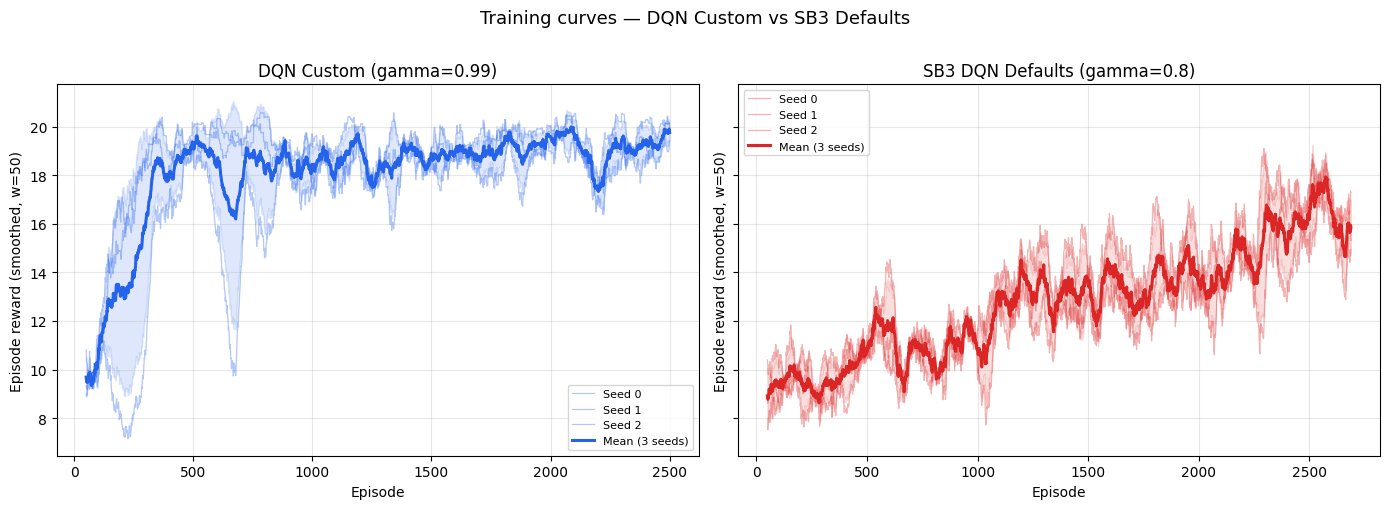

Saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

datasets = [
    (custom, "DQN Custom (gamma=0.99)", CUSTOM_COLOR, axes[0]),
    (sb3,    "SB3 DQN Defaults (gamma=0.8)", SB3_COLOR, axes[1]),
]

for data, title, color, ax in datasets:
    all_r = data["all_rewards"]  # list of 3 lists (one per seed)
    W = 50
    smoothed = [smooth(np.array(r), W) for r in all_r]
    min_len = min(len(s) for s in smoothed)
    smoothed = np.array([s[:min_len] for s in smoothed])
    episodes = np.arange(min_len) + W

    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)

    for i, (s, seed) in enumerate(zip(smoothed, SEEDS)):
        ax.plot(episodes, s, alpha=0.35, linewidth=0.9, color=color,
                label=f"Seed {seed}" if i == 0 else f"Seed {seed}")
    ax.plot(episodes, mean, color=color, linewidth=2.2, label="Mean (3 seeds)")
    ax.fill_between(episodes, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Episode reward (smoothed, w=50)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Training curves — DQN Custom vs SB3 Defaults", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Figure 2 — Evaluation results per seed

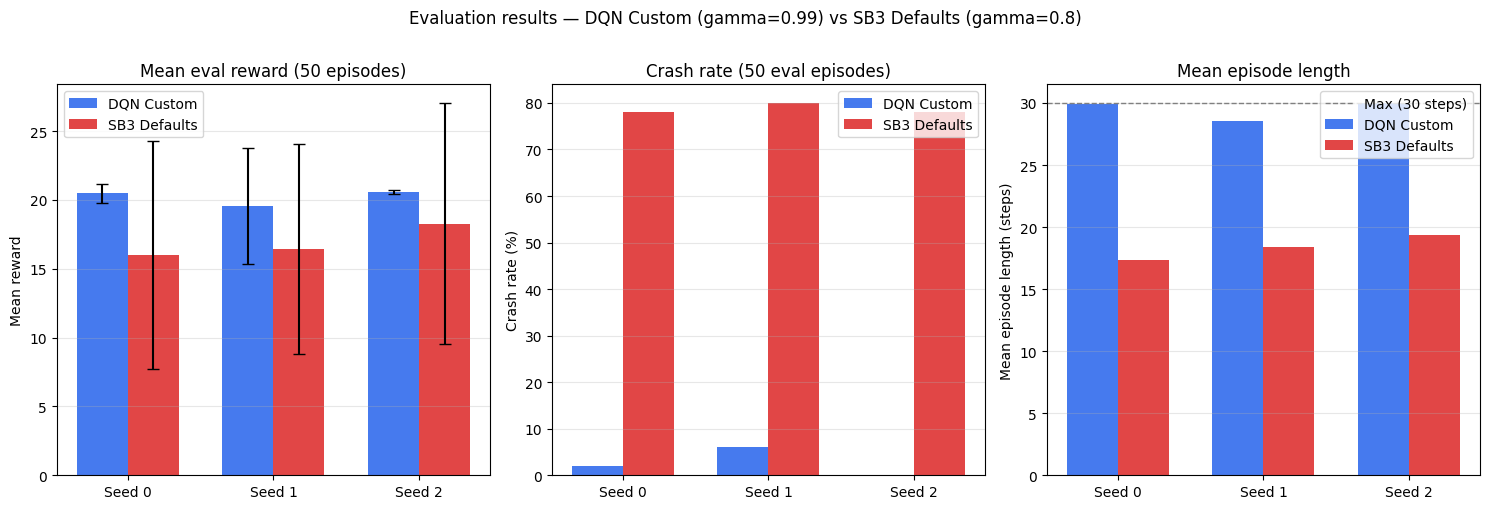

Saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def per_seed_values(data, key):
    return [s["eval"][key] for s in data["per_seed"]]

def per_seed_std(data, key):
    return [s["eval"].get("std_" + key.split("_")[0], 0) for s in data["per_seed"]]

x = np.arange(len(SEEDS))
w = 0.35
seed_labels = [f"Seed {s}" for s in SEEDS]

# Mean reward
ax = axes[0]
c_means = per_seed_values(custom, "mean_reward")
c_stds  = [s["eval"]["std_reward"] for s in custom["per_seed"]]
s_means = per_seed_values(sb3, "mean_reward")
s_stds  = [s["eval"]["std_reward"] for s in sb3["per_seed"]]

bars1 = ax.bar(x - w/2, c_means, w, yerr=c_stds, capsize=4,
               color=CUSTOM_COLOR, alpha=0.85, label="DQN Custom")
bars2 = ax.bar(x + w/2, s_means, w, yerr=s_stds, capsize=4,
               color=SB3_COLOR, alpha=0.85, label="SB3 Defaults")
ax.set_xticks(x); ax.set_xticklabels(seed_labels)
ax.set_ylabel("Mean reward")
ax.set_title("Mean eval reward (50 episodes)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# Crash rate
ax = axes[1]
c_crash = [s["eval"]["crash_rate"] * 100 for s in custom["per_seed"]]
s_crash = [s["eval"]["crash_rate"] * 100 for s in sb3["per_seed"]]
ax.bar(x - w/2, c_crash, w, color=CUSTOM_COLOR, alpha=0.85, label="DQN Custom")
ax.bar(x + w/2, s_crash, w, color=SB3_COLOR,    alpha=0.85, label="SB3 Defaults")
ax.set_xticks(x); ax.set_xticklabels(seed_labels)
ax.set_ylabel("Crash rate (%)")
ax.set_title("Crash rate (50 eval episodes)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# Episode length
ax = axes[2]
c_len = [s["eval"]["mean_length"] for s in custom["per_seed"]]
s_len = [s["eval"]["mean_length"] for s in sb3["per_seed"]]
ax.bar(x - w/2, c_len, w, color=CUSTOM_COLOR, alpha=0.85, label="DQN Custom")
ax.bar(x + w/2, s_len, w, color=SB3_COLOR,    alpha=0.85, label="SB3 Defaults")
ax.set_xticks(x); ax.set_xticklabels(seed_labels)
ax.set_ylabel("Mean episode length (steps)")
ax.set_title("Mean episode length")
ax.axhline(30, color="grey", linestyle="--", linewidth=1, label="Max (30 steps)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Evaluation results — DQN Custom (gamma=0.99) vs SB3 Defaults (gamma=0.8)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT / "eval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Figure 3 — Reward distribution (violin plots)

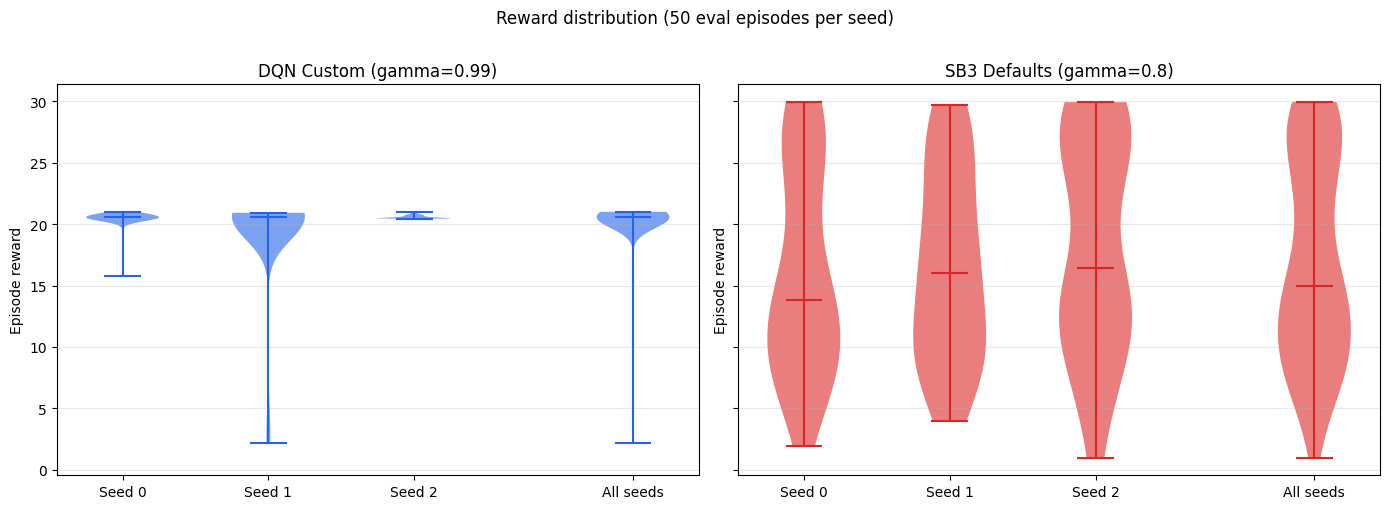

Saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for data, title, color, ax in [
    (custom, "DQN Custom (gamma=0.99)", CUSTOM_COLOR, axes[0]),
    (sb3,    "SB3 Defaults (gamma=0.8)", SB3_COLOR,   axes[1]),
]:
    rewards_per_seed = [s["eval"]["raw_rewards"] for s in data["per_seed"]]
    all_r = [r for rs in rewards_per_seed for r in rs]  # aggregate

    parts = ax.violinplot(
        rewards_per_seed + [all_r],
        positions=[0, 1, 2, 3.5],
        showmedians=True, showextrema=True
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    for key in ["cmedians", "cbars", "cmins", "cmaxes"]:
        parts[key].set_color(color)

    ax.set_xticks([0, 1, 2, 3.5])
    ax.set_xticklabels(["Seed 0", "Seed 1", "Seed 2", "All seeds"])
    ax.set_ylabel("Episode reward")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Reward distribution (50 eval episodes per seed)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT / "reward_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Figure 4 — Aggregate comparison (summary bar)

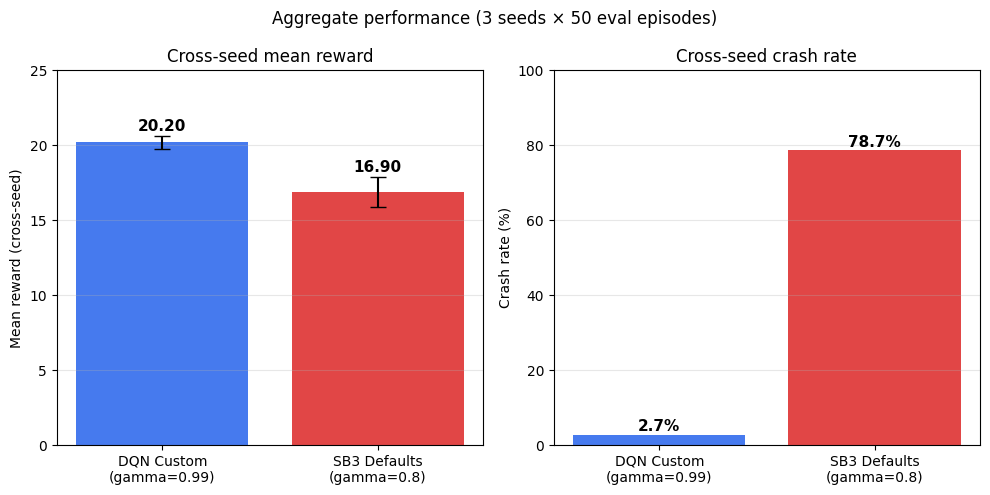

Saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ["DQN Custom\n(gamma=0.99)", "SB3 Defaults\n(gamma=0.8)"]
colors = [CUSTOM_COLOR, SB3_COLOR]

# Aggregate mean reward
agg_rewards = [
    custom["aggregate"]["mean_reward"],
    sb3["aggregate"]["mean_reward"],
]
agg_stds = [
    custom["aggregate"]["std_reward"],
    sb3["aggregate"]["std_reward"],
]
axes[0].bar(labels, agg_rewards, color=colors, alpha=0.85, yerr=agg_stds, capsize=6)
axes[0].set_ylabel("Mean reward (cross-seed)")
axes[0].set_title("Cross-seed mean reward")
for i, (v, e) in enumerate(zip(agg_rewards, agg_stds)):
    axes[0].text(i, v + e + 0.3, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_ylim(0, 25)

# Aggregate crash rate
agg_crash = [
    custom["aggregate"]["crash_rate"] * 100,
    sb3["aggregate"]["crash_rate"] * 100,
]
axes[1].bar(labels, agg_crash, color=colors, alpha=0.85)
axes[1].set_ylabel("Crash rate (%)")
axes[1].set_title("Cross-seed crash rate")
for i, v in enumerate(agg_crash):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 100)

plt.suptitle("Aggregate performance (3 seeds × 50 eval episodes)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / "aggregate_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Figure 5 — DQN Custom: gamma ablation (context)

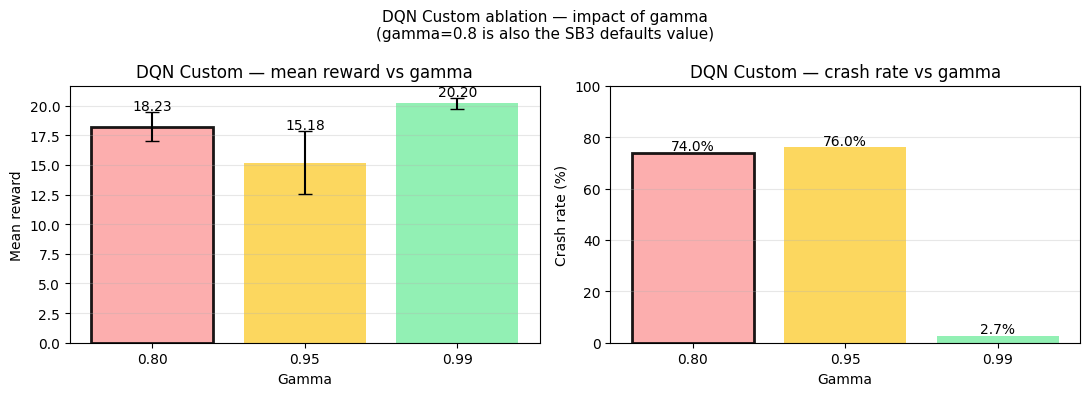

Saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gammas = ["0.8", "0.95", "0.99"]
gamma_labels = ["0.80", "0.95", "0.99"]
x = np.arange(len(gammas))
abl_colors = ["#FCA5A5", "#FCD34D", "#86EFAC"]  # red → yellow → green

mean_r = [ablation[g]["aggregate"]["mean_reward"] for g in gammas]
std_r  = [ablation[g]["aggregate"]["std_reward"] for g in gammas]
crash  = [ablation[g]["aggregate"]["crash_rate"] * 100 for g in gammas]

axes[0].bar(gamma_labels, mean_r, color=abl_colors, alpha=0.9, yerr=std_r, capsize=5)
for i, (v, e) in enumerate(zip(mean_r, std_r)):
    axes[0].text(i, v + e + 0.2, f"{v:.2f}", ha="center", fontsize=10)
axes[0].set_xlabel("Gamma")
axes[0].set_ylabel("Mean reward")
axes[0].set_title("DQN Custom — mean reward vs gamma")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(gamma_labels, crash, color=abl_colors, alpha=0.9)
for i, v in enumerate(crash):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_xlabel("Gamma")
axes[1].set_ylabel("Crash rate (%)")
axes[1].set_title("DQN Custom — crash rate vs gamma")
axes[1].set_ylim(0, 100)
axes[1].grid(axis="y", alpha=0.3)

# Annotate the gamma=0.8 shared with SB3 defaults
for ax in axes:
    ax.get_children()[0].set_edgecolor("black")
    ax.get_children()[0].set_linewidth(2)

plt.suptitle("DQN Custom ablation — impact of gamma\n"
             "(gamma=0.8 is also the SB3 defaults value)", fontsize=11)
plt.tight_layout()
plt.savefig(OUT / "gamma_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Figure 6 — Side-by-side training curves (single figure for report)

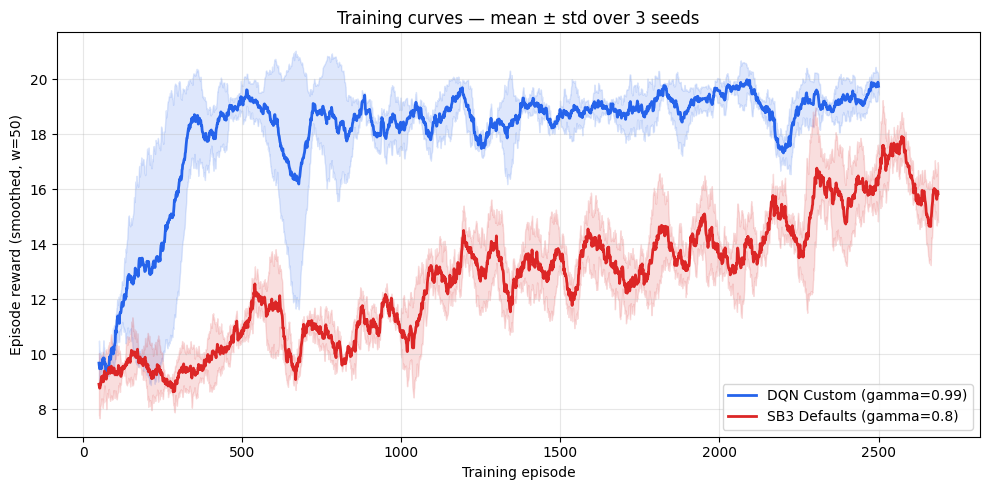

Saved.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for data, label, color in [
    (custom, "DQN Custom (gamma=0.99)", CUSTOM_COLOR),
    (sb3,    "SB3 Defaults (gamma=0.8)", SB3_COLOR),
]:
    W = 50
    smoothed = [smooth(np.array(r), W) for r in data["all_rewards"]]
    min_len  = min(len(s) for s in smoothed)
    smoothed = np.array([s[:min_len] for s in smoothed])
    episodes = np.arange(min_len) + W

    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)

    ax.plot(episodes, mean, color=color, linewidth=2, label=label)
    ax.fill_between(episodes, mean - std, mean + std, alpha=0.15, color=color)

ax.set_xlabel("Training episode")
ax.set_ylabel("Episode reward (smoothed, w=50)")
ax.set_title("Training curves — mean ± std over 3 seeds")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "training_curves_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

## Summary table (print)

In [10]:
print("=" * 60)
print(f"{'Metric':<25} {'DQN Custom':>15} {'SB3 Defaults':>15}")
print("=" * 60)

metrics = [
    ("Mean reward",   "mean_reward", "{:.2f}"),
    ("Std reward",    "std_reward",  "{:.3f}"),
    ("Crash rate",    "crash_rate",  "{:.1%}"),
]
for name, key, fmt in metrics:
    cv = custom["aggregate"][key]
    sv = sb3["aggregate"][key]
    print(f"{name:<25} {fmt.format(cv):>15} {fmt.format(sv):>15}")

print("-" * 60)
print("Per-seed crash rates:")
for s in SEEDS:
    cc = custom["per_seed"][s]["eval"]["crash_rate"]
    sc = sb3["per_seed"][s]["eval"]["crash_rate"]
    print(f"  Seed {s}: Custom {cc:.0%}   SB3 {sc:.0%}")

Metric                         DQN Custom    SB3 Defaults
Mean reward                         20.20           16.90
Std reward                          0.449           0.995
Crash rate                           2.7%           78.7%
------------------------------------------------------------
Per-seed crash rates:
  Seed 0: Custom 2%   SB3 78%
  Seed 1: Custom 6%   SB3 80%
  Seed 2: Custom 0%   SB3 78%
